In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import struct

sns.set_theme()

In [27]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/"

train_labels_path = data_dir + "MNIST-Dataset/train-labels.idx1-ubyte"
train_images_path = data_dir + "MNIST-Dataset/train-images.idx3-ubyte"
test_labels_path = data_dir + "MNIST-Dataset/t10k-labels.idx1-ubyte"
test_images_path = data_dir + "MNIST-Dataset/t10k-images.idx3-ubyte"

def read_labels(labels_path):
    with open(labels_path, "rb") as file:
        magic, size = struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels

def read_images(images_path):
    with open(images_path, "rb") as file:
        magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
        image_data = np.frombuffer(file.read(), dtype=np.uint8)
        final_image_data = np.empty((size, rows, cols), dtype=np.uint8)
        for i in range(size):
            img = image_data[i*rows*cols:(i+1)*rows*cols].reshape(rows, cols)
            final_image_data[i, :, :] = img
        return final_image_data
train_labels = read_labels(train_labels_path)
train_images = read_images(train_images_path)
test_labels = read_labels(test_labels_path)
test_images = read_images(test_images_path)

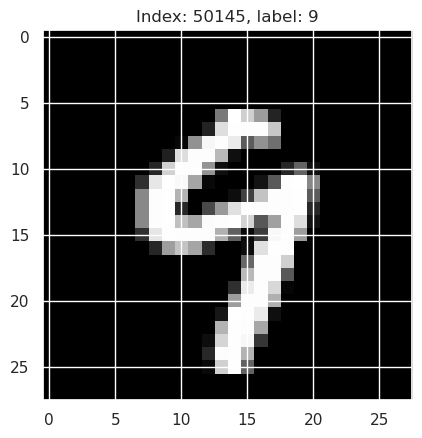

In [30]:
def show_image(images, labels, index):
    plt.imshow(images[index, :, :], cmap=plt.cm.gray)
    plt.title(f"Index: {index}, label: {labels[index]}")
    plt.show()

show_image(train_images, train_labels, 50145)

In [ ]:
class Neuron():
    # just an object to store weights + activations
    def __init__(self, _num_weights, _activation_function):
        self.weights = np.random.rand(_num_weights)
        self.bias = np.random.rand()
        self.activation_function = _activation_function

    def predict(self, X):
        # gets activation from x and weights/bias
        # where X is an array of activations from the previous layer

        # for example, for a neuron in the final layer: there are 16 weights, activation is sigmoid.
        # with a batch of 100 training examples: X has dimension 100 by 16, weights is 16 by 1, so product is 100 by 1. 
        return self.activation_function(np.dot(X, self.weights) + self.bias)

In [ ]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [ ]:
class MultilayerPerceptron():
    def __init__(self, _layer_counts):
        # layer_counts is a list of the number of neurons to place in each hidden layer. The length
        # of layer_counts indicates how many hidden layers there are.
        self.layer_counts = _layer_counts

    def train(self, X, y, possible_outputs, eta = 0.001, epochs = 1000):
        # first extract dimensional information
        self.dim = X.shape[0]
        self.rows, self.cols = X.shape[1], X.shape[2]
        neurons = []

        # first layer neurons are just the values of the image, no neurons necessary

        for (i, layer) in enumerate(self.layer_counts):
            # create neuron layer
            num_weights = self.rows*self.cols if i == 1 else self.layer_counts[i-1]
            neurons.append([Neuron(num_weights, sigmoid) for _ in range(layer)])

        # final layer
        num_weights = self.layer_counts[-1]
        neurons.append([Neuron.num_weights, sigmoid] for _ in range(possible_outputs))
        self.neurons = neurons
        
        # first layer has self.rows * self.cols neurons
        # final layer has 10 neurons

        # what to code here?
        # first off: feedforward
        # then: backprop for a sample of the dataset
        # how to store weights? should probably just store neuron objects

    def feed_forward(self, X):
        # X: 100 rows, 784 columns (pixel data)
        for neuron_layer in self.neurons:
            pass


In [34]:
nn = MultilayerPerceptron([16, 16])
errors = nn.train(train_images, train_labels)

(60000, 28, 28)
